In [3]:
# Quantum Algorithms Demo
# =======================
# This notebook demonstrates three foundational quantum algorithms:
# 1. Quantum Teleportation
# 2. Deutsch-Jozsa Algorithm
# 3. Grover's Search Algorithm

# Import necessary libraries
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Set up the simulator
simulator = Aer.get_backend('qasm_simulator')

In [ ]:
#Quantum Teleportation

Teleportation result: {'001': 248, '010': 248, '111': 254, '100': 250}


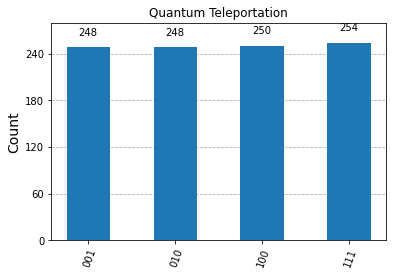

In [6]:

# Teleports the state of a qubit from Alice to Bob using entanglement.

# Create a quantum circuit with 3 qubits and 3 classical bits
qc_teleport = QuantumCircuit(3, 3)

# Step 1: Create entanglement between qubits 1 and 2
qc_teleport.h(1)
qc_teleport.cx(1, 2)

# Step 2: Encode the state to teleport (qubit 0)
qc_teleport.x(0)  # Alice prepares her qubit in state |1>
qc_teleport.barrier()

# Step 3: Alice performs a CNOT and Hadamard on her qubits
qc_teleport.cx(0, 1)
qc_teleport.h(0)
qc_teleport.barrier()

# Step 4: Measure Alice's qubits
qc_teleport.measure([0, 1], [0, 1])

# Step 5: Bob applies corrections based on Alice's measurements
qc_teleport.cz(1, 2)
qc_teleport.cx(0, 2)

# Step 6: Measure Bob's qubit
qc_teleport.measure(2, 2)

# Simulate
job = simulator.run(qc_teleport, shots=1000)
result = job.result()
counts_teleport = result.get_counts(qc_teleport)

print("Teleportation result:", counts_teleport)
plot_histogram(counts_teleport, title="Quantum Teleportation")

Deutsch-Jozsa result: {'0': 1000}


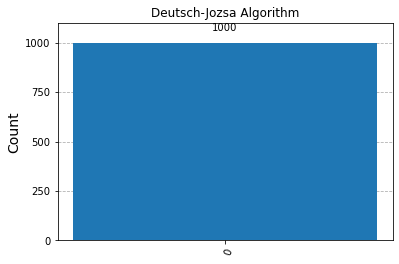

In [7]:
# Deutsch-Jozsa Algorithm
# -----------------------
# Determines if a function is constant or balanced with one query.

# Define a constant function
def constant_oracle(qc, qubits):
    return qc  # Does nothing (constant function)

# Define a balanced function
def balanced_oracle(qc, qubits):
    qc.cx(qubits[0], qubits[1])
    return qc

# Create a 2-qubit circuit
qc_deutsch = QuantumCircuit(2, 1)

# Apply Hadamard gates
qc_deutsch.h([0, 1])

# Apply the balanced oracle
qc_deutsch = balanced_oracle(qc_deutsch, [0, 1])

# Apply Hadamard gate again
qc_deutsch.h(0)

# Measure the first qubit
qc_deutsch.measure(0, 0)

# Simulate
job = simulator.run(qc_deutsch, shots=1000)
result = job.result()
counts_deutsch = result.get_counts(qc_deutsch)

print("Deutsch-Jozsa result:", counts_deutsch)
plot_histogram(counts_deutsch, title="Deutsch-Jozsa Algorithm")

Grover's search result: {'00': 247, '10': 274, '01': 231, '11': 248}


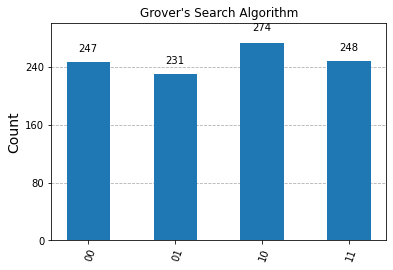

In [9]:
# Grover's Search Algorithm
# -------------------------
# Searches an unstructured database quadratically faster than classical methods.

# Define the oracle for Grover's algorithm (marks the solution |11>)
def grover_oracle(qc, qubits):
    qc.cz(qubits[0], qubits[1])
    qc.cz(qubits[0], qubits[2])
    qc.ccx(qubits[1], qubits[2], qubits[3])
    return qc

# Define the diffusion operator
def diffusion_operator(qc, qubits):
    qc.h(qubits[:3])
    qc.x(qubits[:3])
    qc.h(qubits[2])
    qc.mcx(qubits[:2], qubits[2])  # Updated line
    qc.h(qubits[2])
    qc.x(qubits[:3])
    qc.h(qubits[:3])
    return qc

# Create a 4-qubit circuit (3 qubits + 1 ancilla)
qc_grover = QuantumCircuit(4, 2)

# Initialize qubits
qc_grover.h([0, 1, 2])
qc_grover.x(3)
qc_grover.h(3)

# Apply Grover's iteration (oracle + diffusion)
qc_grover = grover_oracle(qc_grover, [0, 1, 2, 3])
qc_grover = diffusion_operator(qc_grover, [0, 1, 2])

# Measure the first 2 qubits
qc_grover.measure([0, 1], [0, 1])

# Simulate
job = simulator.run(qc_grover, shots=1000)
result = job.result()
counts_grover = result.get_counts(qc_grover)

print("Grover's search result:", counts_grover)
plot_histogram(counts_grover, title="Grover's Search Algorithm")


Quantum Teleportation Circuit:


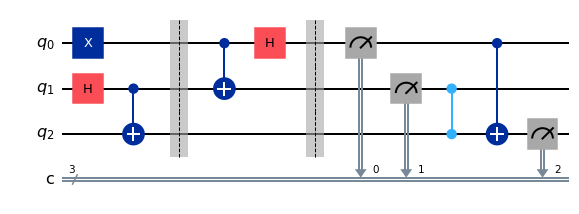


Deutsch-Jozsa Circuit:


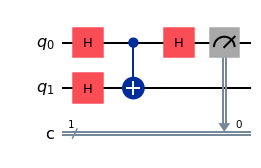


Grover's Search Circuit:


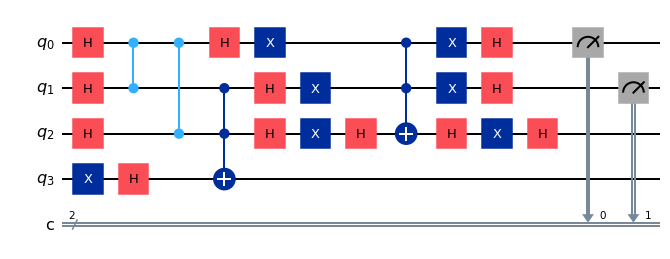

In [10]:
# Visualize all circuits
print("\nQuantum Teleportation Circuit:")
display(qc_teleport.draw('mpl'))

print("\nDeutsch-Jozsa Circuit:")
display(qc_deutsch.draw('mpl'))

print("\nGrover's Search Circuit:")
display(qc_grover.draw('mpl'))

In [11]:
from IPython.display import Markdown

comparison_table = """
| Algorithm               | Purpose                                      | Quantum Advantage                          | Classical Equivalent                     | Result Interpretation                     |
|-------------------------|----------------------------------------------|--------------------------------------------|------------------------------------------|-------------------------------------------|
| **Quantum Teleportation** | Transfer a quantum state using entanglement | Demonstrates entanglement and no-cloning  | No direct equivalent                    | Bob's qubit matches Alice's original state |
| **Deutsch-Jozsa**        | Classify a function as constant or balanced | Solves in 1 query (classical needs many)   | Requires exponential queries            | 0=constant, 1=balanced                     |
| **Grover's Search**      | Search an unstructured database              | Quadratic speedup                         | Linear search                            | Solution state is amplified                |
"""

display(Markdown(comparison_table))


| Algorithm               | Purpose                                      | Quantum Advantage                          | Classical Equivalent                     | Result Interpretation                     |
|-------------------------|----------------------------------------------|--------------------------------------------|------------------------------------------|-------------------------------------------|
| **Quantum Teleportation** | Transfer a quantum state using entanglement | Demonstrates entanglement and no-cloning  | No direct equivalent                    | Bob's qubit matches Alice's original state |
| **Deutsch-Jozsa**        | Classify a function as constant or balanced | Solves in 1 query (classical needs many)   | Requires exponential queries            | 0=constant, 1=balanced                     |
| **Grover's Search**      | Search an unstructured database              | Quadratic speedup                         | Linear search                            | Solution state is amplified                |
